In [2]:
import numpy as np
_dataset_path = "mapelite/datasets/track_embeddings_metrics_32dim_rngMixDS_tita_circular_1.npz"
EMBEDDING_MODEL_PATH = "mapelite/embeddings/models/model_metrics_VAE/model_metrics_VAE_mixRng_tita_circular_1.pth"
_data = np.load(_dataset_path)
_embeddings = _data["embeddings"]


# pairwise distances
from scipy.spatial.distance import pdist, squareform
distances = pdist(_embeddings, metric="euclidean")

max_distance = np.max(distances)
min_distance = np.min(distances)
average_distance = np.mean(distances)

diff = max_distance - min_distance
y = diff / min_distance

print(f"Max distance: {max_distance}")
print(f"Min distance: {min_distance}")
print(f"Difference: {diff}")
print(f"Difference / Min distance: {y}")
print(f"Average distance: {average_distance}")

Max distance: 16.0243667584528
Min distance: 0.15874021297250948
Difference: 15.865626545480291
Difference / Min distance: 99.94711641358255
Average distance: 7.002284298866627


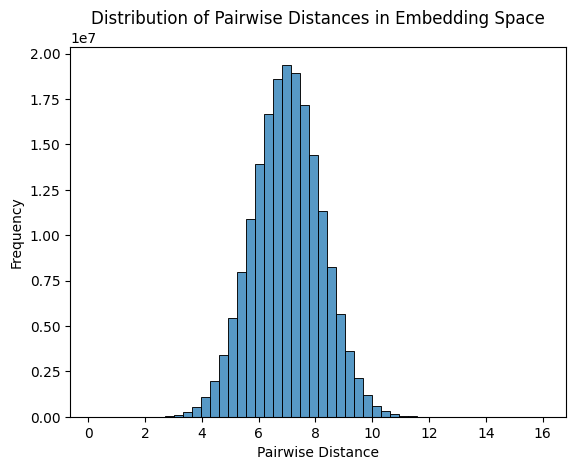

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(distances, bins=50, kde=True)
plt.xlabel("Pairwise Distance")
plt.ylabel("Frequency") 
plt.title("Distribution of Pairwise Distances in Embedding Space")
plt.show()

Dimension 0: Mean = -0.0981, Std Dev = 0.7775
Dimension 1: Mean = 0.0210, Std Dev = 0.9574
Dimension 2: Mean = -0.0497, Std Dev = 0.8907
Dimension 3: Mean = 0.0893, Std Dev = 0.9560
Dimension 4: Mean = 0.0749, Std Dev = 0.1984
Dimension 5: Mean = 0.0960, Std Dev = 0.9571
Dimension 6: Mean = -0.0167, Std Dev = 0.9665
Dimension 7: Mean = -0.0493, Std Dev = 0.9303
Dimension 8: Mean = 0.0429, Std Dev = 0.9000
Dimension 9: Mean = 0.1001, Std Dev = 0.9045
Dimension 10: Mean = 0.0615, Std Dev = 0.8594
Dimension 11: Mean = 0.0834, Std Dev = 0.8709
Dimension 12: Mean = 0.0375, Std Dev = 0.9748
Dimension 13: Mean = -0.0068, Std Dev = 0.0642
Dimension 14: Mean = 0.0578, Std Dev = 0.9726
Dimension 15: Mean = -0.0265, Std Dev = 0.8509
Dimension 16: Mean = 0.1330, Std Dev = 0.9499
Dimension 17: Mean = -0.0180, Std Dev = 0.9479
Dimension 18: Mean = -0.0265, Std Dev = 0.9613
Dimension 19: Mean = -0.1079, Std Dev = 0.9159
Dimension 20: Mean = -0.0615, Std Dev = 0.9277
Dimension 21: Mean = 0.0958, Std D

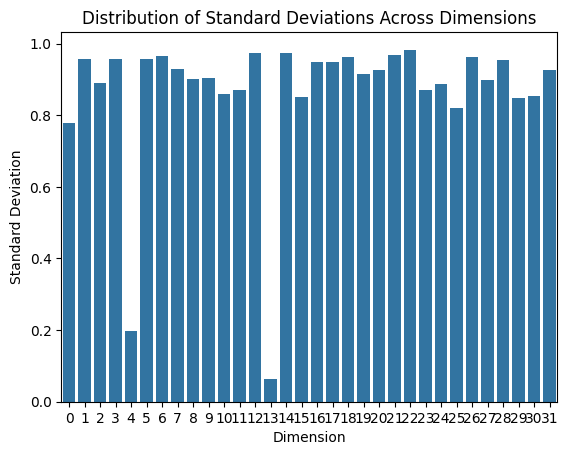

In [4]:
# for each dimention calculate the mean and std_deviation
for i in range(_embeddings.shape[1]):
    dim_values = _embeddings[:, i]
    mean = np.mean(dim_values)
    std_dev = np.std(dim_values)
    print(f"Dimension {i}: Mean = {mean:.4f}, Std Dev = {std_dev:.4f}")
    
# make a barplot of the std_deviation of each dimension
std_devs = [np.std(_embeddings[:, i]) for i in range(_embeddings.shape[1])]
sns.barplot(x=list(range(len(std_devs))), y=std_devs)
plt.xlabel("Dimension")
plt.ylabel("Standard Deviation")
plt.title("Distribution of Standard Deviations Across Dimensions")
plt.show()

Autovalori: [0.00358767 0.03875705 0.27993182 1.36607318 0.40261067 0.42210566
 0.44150917 1.26728044 0.51119789 0.53691365 1.21235026 1.19355152
 1.16018508 1.13530332 0.58464967 1.08384523 1.07180428 1.03811401
 0.62915221 0.65397974 0.99583324 0.96497852 0.94661259 0.9123549
 0.8935618  0.8664084  0.72072731 0.749977   0.74819989 0.78146812
 0.81904979 0.79893407]


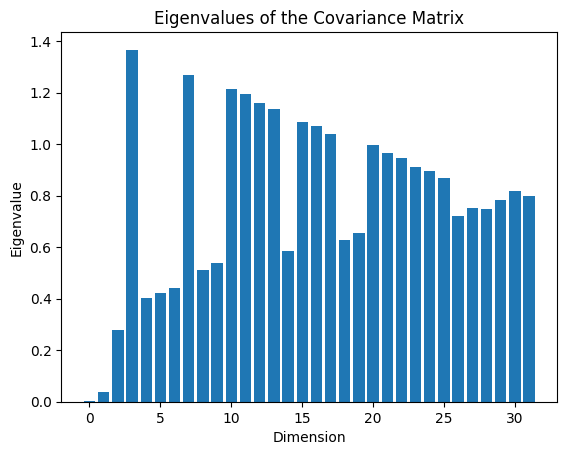

In [5]:
# covariance matrix and eigenvalues
cov_matrix = np.cov(_embeddings, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
print("Autovalori:", eigenvalues)

# bar plot of eigenvalues
plt.bar(range(len(eigenvalues)), eigenvalues)
plt.xlabel("Dimension")
plt.ylabel("Eigenvalue")
plt.title("Eigenvalues of the Covariance Matrix")
plt.show()